Checking Qiskit installation...
Qiskit Version: 2.4.0

Circuit Diagram Successfully Generated:


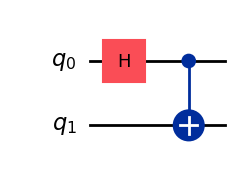

In [1]:
import qiskit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit

# 1. Check if the libraries are installed correctly
print("Checking Qiskit installation...")
print(f"Qiskit Version: {qiskit.__version__}")

# 2. Create a basic Bell State circuit (The 'Hello World' of Quantum)
# This creates a 2-qubit circuit
qc = QuantumCircuit(2)

# Apply a Hadamard gate to qubit 0 (Superposition)
qc.h(0)

# Apply a CNOT gate with qubit 0 as control and qubit 1 as target (Entanglement)
qc.cx(0, 1)

# 3. Draw the circuit to make sure the graphics work
print("\nCircuit Diagram Successfully Generated:")
qc.draw('mpl')


Experimental Results: {'00': 508, '11': 516}


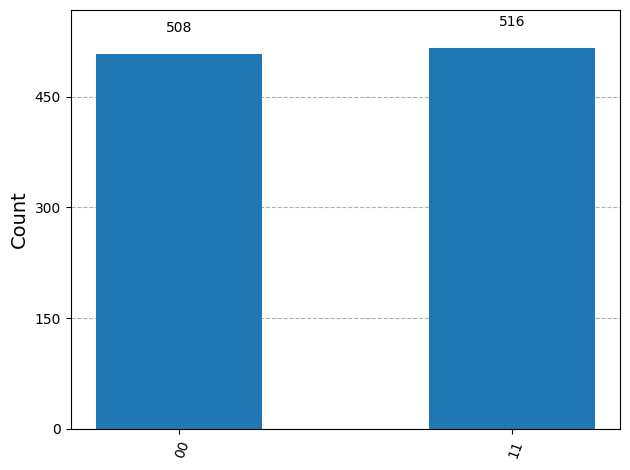

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Initialize a 2-qubit circuit with 2 classical bits for measurement
qc = QuantumCircuit(2, 2)

# 2. Add Gates to create Entanglement
qc.h(0)          # Step 1: Put Qubit 0 into Superposition (50/50 chance of 0 or 1)
qc.cx(0, 1)      # Step 2: CNOT Gate. This links Qubit 1 to Qubit 0.

# 3. Measurement (Observe the results)
qc.measure([0, 1], [0, 1])

# 4. Run the Simulation
simulator = AerSimulator()
job = simulator.run(qc, shots=1024) # Run the experiment 1024 times
result = job.result()

# 5. Get the data
counts = result.get_counts()
print(f"Experimental Results: {counts}")

# 6. Plot the outcome
plot_histogram(counts)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# 1. Use your NEW token here
TOKEN = ""
MY_CRN = "crn:v1:bluemix:public:quantum-computing:us-east:a/85a1f841a9be4ebe9c07ccec7b8518c9:82614a4c-0180-41c5-b4f7-0a1ce866732d::"
# 2. We use 'ibm_quantum'—this is the "Researcher Door" 
# It's much simpler and won't give you that ValueError.
QiskitRuntimeService.save_account(channel="ibm_cloud", token=TOKEN, instance=MY_CRN, overwrite=True)

# 3. Open the connection
service = QiskitRuntimeService(channel="ibm_cloud", instance=MY_CRN)

print("Successfully connected to the IBM Cloud Quantum Lab!")
print(f"Available Backends: {service.backends()}")

Successfully connected to the IBM Cloud Quantum Lab!
Available Backends: [<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>]


In [8]:
from qiskit_aer import AerSimulator

# Instead of asking the Cloud for a simulator, we use your own computer.
# This is much faster for a researcher's workflow.
backend = AerSimulator()

print(f"Target backend set to local: {backend.name}")

Target backend set to local: aer_simulator


In [9]:
from qiskit import QuantumCircuit

# Create a Quantum Circuit with 2 qubits and 2 classical bits
# Syntax: QuantumCircuit(number_of_qubits, number_of_classical_bits)
qc = QuantumCircuit(2, 2)

print("Circuit initialized with 2 qubits and 2 classical bits.")

Circuit initialized with 2 qubits and 2 classical bits.


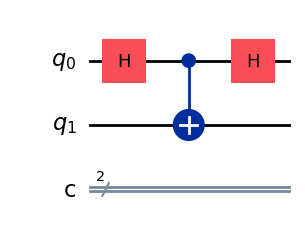

In [12]:
# Apply a Hadamard gate to qubit 0
qc.h(0)

# Draw the circuit using the Matplotlib renderer for research-grade visuals
qc.draw('mpl')

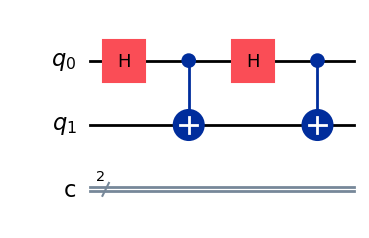

In [13]:
# Apply a CNOT gate (Control=0, Target=1)
qc.cx(0, 1)

# Draw the updated, entangled circuit
qc.draw('mpl')

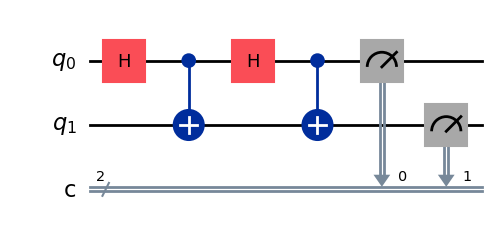

In [14]:
# Measure qubit 0 into classical bit 0, and qubit 1 into classical bit 1
qc.measure([0, 1], [0, 1])

# Draw the final complete circuit
qc.draw('mpl')

Fresh Data Generated: {'00': 515, '11': 509}


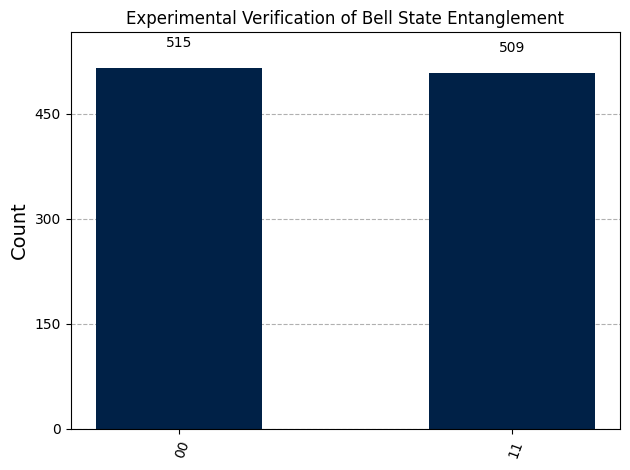

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Initialize a fresh circuit 
qc = QuantumCircuit(2, 2)

# 2. Build the exact Bell State
qc.h(0)           
qc.cx(0, 1)       

# 3. Measure the results
qc.measure([0, 1], [0, 1])

# 4. Run the experiment
backend = AerSimulator()
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit, shots=1024)
counts = job.result().get_counts()

# Print the raw data to prove the experiment ran
print(f"Fresh Data Generated: {counts}")

# 5. Generate the visual (Leaving the variable on the last line forces VS Code to display it)
fig = plot_histogram(counts, color='#002147', title="Experimental Verification of Bell State Entanglement")
fig

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Wake up your connection to the IBM Cloud
service = QiskitRuntimeService(channel="ibm_cloud")

# 2. Ask IBM for the real processor with the shortest queue
real_backend = service.least_busy(simulator=False, operational=True)
print(f"Targeting Real Quantum Hardware: {real_backend.name}")

# 3. Transpile your circuit for this specific machine using the new Pass Manager
pm = generate_preset_pass_manager(backend=real_backend, optimization_level=1)
isa_circuit = pm.run(qc)

# 4. Submit the job to the cloud queue using the modern Sampler Primitive
sampler = Sampler(mode=real_backend)
sampler.options.default_shots = 1024
job = sampler.run([isa_circuit])

print(f"Success! Job ID: {job.job_id()}")
print("Your experiment is now queued at an IBM facility.")

Targeting Real Quantum Hardware: ibm_fez
Success! Job ID: d7l6tp28ui0s73b622d0
Your experiment is now queued at an IBM facility.


Archived Hardware Data: {'00': 486, '11': 458, '01': 32, '10': 48}


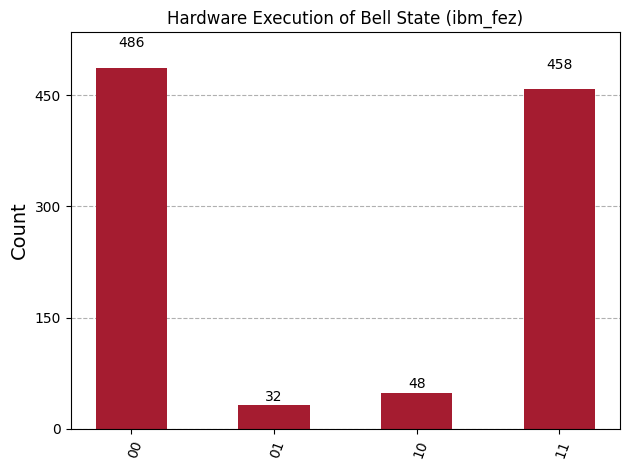

In [9]:
%matplotlib inline
from qiskit.visualization import plot_histogram

# Data successfully retrieved from physical backend 'ibm_fez' 
# Job ID: d7l6tp28ui0s73b622d0
real_counts = {'00': 486, '11': 458, '01': 32, '10': 48}

print(f"Archived Hardware Data: {real_counts}")

# Generate the plot (assigning it to 'fig' without calling it at the end stops the double-print)
fig = plot_histogram(real_counts, color='#A51C30', title="Hardware Execution of Bell State (ibm_fez)")